In [143]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Use a pipeline as a high-level helper
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [168]:
ara_data_folder = "../../data/newsapi/downloads/ara/"
eng_data_folder = "../../data/newsapi/downloads/eng/"

In [178]:
ara = pd.read_csv(ara_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_ara.csv")
eng = pd.read_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_eng.csv") 

In [179]:
eng.shape

(86660, 20)

In [183]:
mb_per_eng =  460 / 85000
mb_eng_total = mb_per_eng * 10000000


The downloaded data for all articles in Arabic requires around 54.12 GB


In [185]:
mb_per_ara =  380 / 85000
mb_ara_total = mb_per_ara * 10000000
print(f"The downloaded data for all articles in English requires around {np.round(mb_eng_total/1000,2)} GB")
print(f"The downloaded data for all articles in Arabic requires around {np.round(mb_ara_total/1000,2)} GB")
print(f"The downloaded data for all articles is around {np.round((mb_eng_total + mb_ara_total)/1000,2)} GB")

The downloaded data for all articles in English requires around 54.12 GB
The downloaded data for all articles in Arabic requires around 44.71 GB
The downloaded data for all articles is around 98.82 GB


44705.882352941175

In [ ]:
mb_per_ara

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-ar-en")
model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-ar-en")

In [78]:
original_texts = []
translated_texts = []
for i in range(30):
    sample_text = ara["title"][i]
    sample_text = sample_text.replace('"', '')
    batch = tokenizer([sample_text], return_tensors="pt")

    generated_ids = model.generate(**batch)
    original_texts.append(sample_text)
    translated_texts.append(tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0])
    print(f"{i}: {tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]} {sample_text}")

0: Press today: 12-7-2024 الصحافة اليوم: 12-7-2024
1: The explosion in southern Lebanon... the lion is present with no tools. انفجار جنوبي لبنان.. الأسد حاضر دون أدوات
2: Press today: 1-7-2024 الصحافة اليوم: 1-7-2024
3: The Palestinian writer, two quarter of the fatty, in a lengthy dialogue: the Palestinian novel, success and presence... and the earthquake revealed Israel's lies. الكاتب الفلسطيني ربعي المدهون في حوار مطوّل: الرواية الفلسطينية حققت نجاحًا وحضورًا.. والحرب زلزال كشف كذب السردية الإسرائيلية
4: Far flood: the need for war... post-Pax America. طوفان الأقصى: الحاجة إلى الحرب.. مرحلة ما بعد باكس أمريكانا
5: Informing the system is about a consensus to hold a meeting of the Arab Ministerial Liaison Committee in Baghdad. إعلام النظام يتحدث عن توافق لعقد اجتماع لجنة الاتصال الوزارية العربية في بغداد
6: Press today: 9-7-2024 الصحافة اليوم: 9-7-2024
7: The Palestinian writer, two quarter of the fatty, in a lengthy dialogue: the Palestinian novel, success and presence... and the ea

In [93]:
df = pd.DataFrame({"original": original_texts, "helsinki_model": translated_texts})

In [94]:
google_translations = ["Today's Press: 12-7-2024", 
 "Explosion in southern Lebanon.. Assad is present without tools", 
 "Today's Press: 1-7-2024", 
 "Palestinian writer Rabai Al-Madhoun in an extended interview: The Palestinian novel has achieved success and presence... and the war is an earthquake that exposed the lies of the Israeli narrative", 
 "The Flood of Al-Aqsa: The Need for War... Post-Pax Americana", 
 "Regime media talks about agreement to hold a meeting of the Arab Ministerial Contact Committee in Baghdad", 
 "Today's Press: 9-7-2024",
 "Palestinian writer Rabie Al-Madhoun in an extended interview: The Palestinian novel has achieved success and presence... and the war is an earthquake that exposed the lies of the Israeli narrative - Al-Shorouk Gate - Mobile version",
 "Today's Press: 3-7-2024",
 "AFC announces schedule of matches for 2019 Asian Cup - Hiba Press",
 "Al-Akhdar meets its Yemeni brother in the opening of the Arab Nations Championship",
 "Resistance factions outside Lebanon... Will they join the comprehensive war if it happens?",
 "The political hybrid genre... and the Via Dolorosa",
 "No security for Israel without peace",
 "Paris Olympics 2024.. 129 medals is the historical Arab record in the Olympic Games",
 "Israeli Press Daily File Issued by the Press Office of the Democratic Front for the Liberation of Palestine Monday 7/1/2024 Issue 1042",
 "With the participation of the regime.. Iraq hosts the second conference to combat drugs",
 "Abu Hilalain Empire.. Why is Captagon the most dangerous drug to reach the Arab world?",
 "The youth team leaves for Saudi Arabia.. What do you know about the Arab West Asian Championship?",
 "The youth team leaves for Saudi Arabia to participate in the (Arab Countries) West Asia Championship",
 "Intersection of interests accelerates pace of Ankara-Damascus rapprochement",
 "Israeli warnings of unprecedented security challenges on various fronts",
 "((Youth Football)) seeks the lead in the ((WAF)) Championship",
 "Türkiye and Jordan in the eye of the drug storm (3-3)",
 "Will the Lebanese front ignite, and how much will the Americans get involved in it?",
 "Are the days of sympathy with the Syrians over? | Ali Qasim | Al Arab Newspaper",
 "Today's Press: 7-24-2024",
 "The university... today Hezbollah, tomorrow ISIS!",
 "That the Arab peoples have no relation to the Palestinian issue | Amman Net website",
 "That the Arab peoples have no relation to the Palestinian issue"
 ]

In [95]:
df["google_translate"] = google_translations

In [97]:
df.to_csv(ara_data_folder + "test_translations.csv", index=False)

In [147]:
ara["body_len"] = ara["body"].apply(lambda x: len(x))

In [158]:
ara["body_len"].mean()

np.float64(2141.001602133059)

In [160]:
mean_example = ara.loc[(ara["body_len"] > 2100) & (ara["body_len"] < 2200), "body"].values[0]

In [106]:
body_length = ara["body"].apply(lambda x: len(x)).values

In [145]:
np.median(body_length)

np.float64(1486.0)

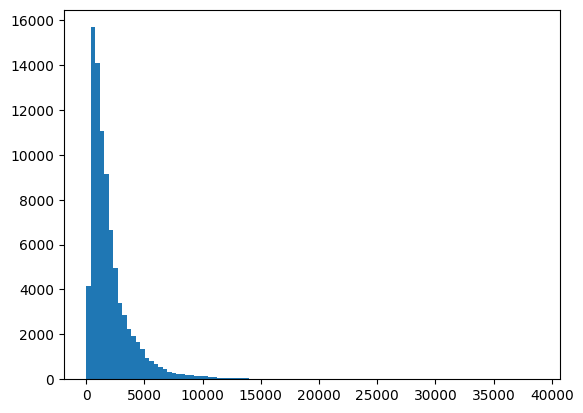

In [154]:
plt.hist(ara["body"].apply(lambda x: len(x)), bins=100)
plt.show()

In [165]:
from transformers import pipeline

translator = pipeline("translation", model="Helsinki-NLP/opus-mt-ar-en")

In [166]:
body1 = mean_example.split(".")

In [167]:
[translator(sentence) for sentence in body1]

[[{'translation_text': 'The number of Iraqi refugees, estimated at 4 million in the world, is increasing steadily, mainly in America, Germany, Britain, European countries, Turkey and some Arab States.'}],
 [{'translation_text': 'Young people make up the largest number of these refugees, many of whom are graduates and highly qualified in important and accurate disciplines of science and knowledge.'}],
 [{'translation_text': 'According to statistics from the Office of the United Nations High Commissioner for Refugees (UNHCR) for 2022-2023, there are 15,214 Iraqi nationals registered as refugees in Syria and 61,993 in Jordan.'}],
 [{'translation_text': 'Turkey has more than 10,000 registered citizens, while there are approximately 132,000 asylum-seekers whose cases have not been resolved'}],
 [{'translation_text': 'There are about 6,500 registered refugees in Lebanon.'}],
 [{'translation_text': 'Jordan, Lebanon, Turkey and Syria, as well as European States such as Sweden, the Netherlands,

In [112]:
original_texts = []
translated_texts = []
for i in range(30):
    sample_text = ara["body"][i]
    sample_text = sample_text.replace('"', '')
    batch = tokenizer([sample_text], return_tensors="pt")

    generated_ids = model.generate(**batch)
    original_texts.append(sample_text)
    translated_texts.append(tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0])
    print(f"{i}: {tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]} {sample_text}")

Token indices sequence length is longer than the specified maximum sequence length for this model (9387 > 512). Running this sequence through the model will result in indexing errors


IndexError: index out of range in self